<a href="https://colab.research.google.com/github/nanasaheb-yadav/snf_mig/blob/main/da.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
import matplotlib
print(matplotlib.__version__)

3.10.0


In [3]:
# prompt: how to read csv file here which i want to use in this code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

# Assuming the uploaded file is named 'your_file.csv'
# Replace 'your_file.csv' with the actual filename if different
try:
  df = pd.read_csv(fn)
  # Now you can work with the dataframe 'df'
  print(df.head()) # Example: print the first 5 rows
except FileNotFoundError:
  print(f"Error: File '{fn}' not found. Please upload the correct file.")
except pd.errors.ParserError:
  print(f"Error: Could not parse the file '{fn}'. Please check the file format.")
except Exception as e:
  print(f"An unexpected error occurred: {e}")

Saving SDA_assignment.csv to SDA_assignment (1).csv
User uploaded file "SDA_assignment (1).csv" with length 820744 bytes
  Channel_group course    lead_id Lead_type         lead_date  \
0             A   Java   1,42,649       ABC  17-05-2024 17:53   
1             A   Java  41,63,228       XYZ  25-05-2024 15:23   
2             B   Java  41,76,457       EFG  06-05-2024 10:12   
3             A   Java   1,36,989       ABC  16-05-2024 12:31   
4             C   Java   1,40,085       ABC  01-05-2024 20:35   

   graduation_year  amount_paid paid_at  
0             2008          NaN     NaN  
1             2009          NaN     NaN  
2             2000          NaN     NaN  
3             2009          NaN     NaN  
4             2002          NaN     NaN  


In [3]:
df

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Channel_group,course,lead_id,Lead_type,lead_date,graduation_year,amount_paid,paid_at
0,A,Java,"1,42,649",ABC,17-05-2024 17:53,2008,NaN,NaN
1,A,Java,"41,63,228",XYZ,25-05-2024 15:23,2009,NaN,NaN
2,B,Java,"41,76,457",EFG,06-05-2024 10:12,2000,NaN,NaN
3,A,Java,"1,36,989",ABC,16-05-2024 12:31,2009,NaN,NaN
4,C,Java,"1,40,085",ABC,01-05-2024 20:35,2002,NaN,NaN
...,...,...,...,...,...,...,...,...
16455,A,Python,"41,79,788",EFG,03-05-2024 05:27,2023,NaN,NaN
16456,B,SEO,"41,73,873",XYZ,04-05-2024 18:40,2009,NaN,NaN
16457,A,SEO,"41,82,565",XYZ,28-05-2024 00:59,2008,NaN,NaN
16458,E,SEO,"41,77,786",XYZ,04-05-2024 07:55,2022,NaN,NaN


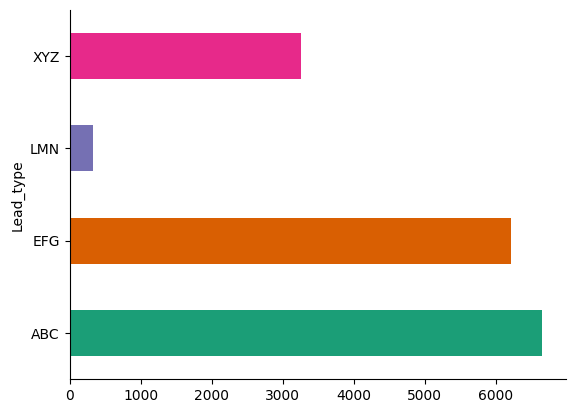

In [11]:
# @title Lead_type

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Lead_type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [5]:
# Set style for better visualizations


# Read the dataset

# Data Cleaning and Preparation
def clean_data(df):
    # Convert lead_date and paid_at to datetime
    df['lead_date'] = pd.to_datetime(df['lead_date'], format='%d-%m-%Y %H:%M')
    df['paid_at'] = pd.to_datetime(df['paid_at'], format='%d-%m-%Y %H:%M', errors='coerce')

    # Clean lead_id (remove commas and convert to numeric)
    df['lead_id'] = df['lead_id'].str.replace(',', '').astype(float)

    # Convert graduation_year to numeric
    df['graduation_year'] = pd.to_numeric(df['graduation_year'])

    return df

# Calculate conversion metrics
def calculate_conversion_metrics(df):
    # Calculate conversion rate by channel
    conversions = df[df['amount_paid'].notna()].groupby('Channel_group').size()
    total_leads = df.groupby('Channel_group').size()
    conversion_rate = (conversions / total_leads * 100).round(2)

    return conversion_rate.sort_values(ascending=False)

# Analyze lead patterns
def analyze_lead_patterns(df):
    # Analyze leads by hour of day
    df['hour'] = df['lead_date'].dt.hour
    hourly_leads = df.groupby('hour').size()

    # Analyze leads by day of week
    df['day_of_week'] = df['lead_date'].dt.day_name()
    daily_leads = df.groupby('day_of_week').size()

    return hourly_leads, daily_leads

# Generate visualizations
def create_visualizations(df):
    # Create output directory if it doesn't exist
    import os
    if not os.path.exists('output/visualizations'):
        os.makedirs('output/visualizations')

    # 1. Channel Distribution
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='Channel_group')
    plt.title('Lead Distribution by Channel')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('output/visualizations/channel_distribution.png')
    plt.close()

    # 2. Course Distribution
    plt.figure(figsize=(10, 6))
    df['course'].value_counts().plot(kind='bar')
    plt.title('Lead Distribution by Course')
    plt.tight_layout()
    plt.savefig('output/visualizations/course_distribution.png')
    plt.close()

    # 3. Conversion Rate by Channel
    conversion_rate = calculate_conversion_metrics(df)
    plt.figure(figsize=(12, 6))
    conversion_rate.plot(kind='bar')
    plt.title('Conversion Rate by Channel (%)')
    plt.tight_layout()
    plt.savefig('output/visualizations/conversion_rate.png')
    plt.close()

    # 4. Lead Generation Time Analysis
    hourly_leads, _ = analyze_lead_patterns(df)
    plt.figure(figsize=(12, 6))
    hourly_leads.plot(kind='line', marker='o')
    plt.title('Lead Generation by Hour of Day')
    plt.xlabel('Hour')
    plt.ylabel('Number of Leads')
    plt.tight_layout()
    plt.savefig('output/visualizations/hourly_pattern.png')
    plt.close()



In [6]:
df = clean_data(df)

In [7]:
conversion_rate = calculate_conversion_metrics(df)
hourly_leads, daily_leads = analyze_lead_patterns(df)

In [8]:
create_visualizations(df)

In [9]:
summary_stats = {
        'total_leads': len(df),
        'total_conversions': df['amount_paid'].notna().sum(),
        'overall_conversion_rate': (df['amount_paid'].notna().sum() / len(df) * 100).round(2),
        'top_channel': df['Channel_group'].mode()[0],
        'top_course': df['course'].mode()[0]
    }

In [10]:
summary_stats

{'total_leads': 16460,
 'total_conversions': 648,
 'overall_conversion_rate': 3.94,
 'top_channel': 'A',
 'top_course': 'Python'}